# TME FORWARD MUSIC

* Songs without UPC will be excluded.
* Songs without ISCR will be granted synthetic ISCR, which is "Song - Artist".

In [307]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [308]:
import pandas as pd
from config import (
    BASE_PATH, 
    TOP_N_SONGS, 
    TOP_N_SONGS_UNIQUE_ISRC,
    TOP_N_ALBUMS, 
    OUTPUT_SONG_REPORT_PATH, 
    OUTPUT_ALBUM_REPORT_PATH,
    OUTPUT_SONG_REPORT_PATH_MONTHLY,
    OUTPUT_ALL_REPORT_PATH,
    OUTPUT_CHART_PATH
)
from pipeline import run_etl_pipeline, clean_and_unify_data
from reporting import generate_song_report, generate_album_report, generate_song_report_by_year
import plotting
import os
import reporting

In [309]:
print(BASE_PATH, '\n', OUTPUT_SONG_REPORT_PATH)

/Users/chu-chun/Mirror/Eva/input/TME/ 
 ../output/FORWARD/TME_Song_Report_Forward.xlsx


In [310]:
# Run the ETL pipeline to ingest files
df_raw = run_etl_pipeline(BASE_PATH)

# Clean dates, unify platforms, and standardize metadata names
df_cleaned = clean_and_unify_data(df_raw)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 285899 entries, 165345 to 112530
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   YearMonth        285899 non-null  object 
 1   Platform         285899 non-null  object 
 2   Song             285899 non-null  object 
 3   ISRC             285899 non-null  object 
 4   Artist           285899 non-null  object 
 5   Album            285899 non-null  object 
 6   UPC              285899 non-null  object 
 7   Revenue          285899 non-null  float64
 8   Total_Clicks     285899 non-null  int64  
 9   source_file      285899 non-null  object 
 10  standard_song    285899 non-null  object 
 11  standard_artist  285899 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 28.4+ MB


## Check non HK songs


In [311]:
# see where non HK songs are (exclude synthetic ISRC)
df_non_HK = df_cleaned[(~df_cleaned['ISRC'].str.startswith('HK', na=False)) & (~df_cleaned['ISRC'].str.contains('-', na=False))]

print("\n--- ISRC 含有非'HK'開頭歌曲的檔案 ---")
df_non_HK.groupby('source_file').agg('size')


--- ISRC 含有非'HK'開頭歌曲的檔案 ---


Series([], dtype: int64)

In [312]:
# count non HK ISRC
df_non_HK['ISRC_code'] = df_non_HK['ISRC'].str.extract(r'^([A-Za-z]{1,3})')[0].str.upper()
df_non_HK['ISRC_code'].value_counts()

Series([], Name: count, dtype: int64)

In [313]:
# exclude some columns and re-order column
df_non_HK_clean = df_non_HK.drop(columns=['standard_song', 'standard_artist'])
isrc_col = df_non_HK_clean.pop('ISRC_code')
df_non_HK_clean.insert(4, 'ISRC_code', isrc_col)

# save non HK data to excel file
output_dir = os.path.dirname(OUTPUT_ALL_REPORT_PATH)
output_file = os.path.join(output_dir, 'non_HK_report.xlsx')
df_non_HK_clean.to_excel(output_file, index=False)


In [314]:
# see where TW songs are
df_tw = df_cleaned[df_cleaned['ISRC'].str.startswith('TW', na=False)]

print("\n--- ISRC 含有'TW'開頭歌曲的檔案 ---")
df_tw.groupby('source_file').agg('size')


--- ISRC 含有'TW'開頭歌曲的檔案 ---


Series([], dtype: int64)

## Investigate NA data

In [315]:
# calculate NA
is_missing = df_cleaned.isna() | (df_cleaned == '') | df_cleaned.astype(str).apply(lambda s: s.str.lower() == 'nan')

missing_summary = pd.DataFrame({
    '缺失值總計 (含空字串/\'nan\')': is_missing.sum(),
    '缺失值比例 (%)': (is_missing.mean() * 100).round(2)
})

print("\n--- 完整缺失值統計 (含空字串與 'nan' 字串) ---")
display(missing_summary.sort_values(by='缺失值總計 (含空字串/\'nan\')', ascending=False))


--- 完整缺失值統計 (含空字串與 'nan' 字串) ---


,缺失值總計 (含空字串/'nan'),缺失值比例 (%)
YearMonth,0,0.0
Platform,0,0.0
Song,0,0.0
ISRC,0,0.0
Artist,0,0.0
Album,0,0.0
UPC,0,0.0
Revenue,0,0.0
Total_Clicks,0,0.0
source_file,0,0.0


In [316]:
missing_upc = df_cleaned[df_cleaned['UPC'].isna()]
missing_upc.head()

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist


In [317]:
# identify NA data in source file
df_cleaned[df_cleaned['UPC'].isna()].groupby('source_file').size()


Series([], dtype: int64)

## Update ISRC for ‘我和你 - 仙杜拉’ and find synthetic ISRC

In [318]:
# update ISRC from "我和你 - 仙杜拉" to 'HKG631874004'
df_cleaned.loc[df_cleaned['ISRC'] == '我和你 - 仙杜拉', 'ISRC'] = 'HKG631874004'

In [319]:
df_with_dash = df_cleaned[df_cleaned['ISRC'].str.contains('-', na=False) & df_cleaned['UPC'].notna()]
missing_isrc = (
    df_with_dash
    .groupby('ISRC')
    .agg(
        song=('standard_song', 'first'),
        artist=('standard_artist', 'first'),
        UPC=('UPC', 'first'),
        album=('Album', 'first')
    )
    .reset_index()
)
missing_isrc

,ISRC,song,artist,UPC,album


## Exclude 1. missing UPC data 2.synthetic ISRC 3. TW songs

In [320]:
# exclude missing UPC data
df_cleaned = df_cleaned[df_cleaned['UPC'].notna()]

In [321]:
# exclude synthetic ISRC data, which contains '-'
df_cleaned = df_cleaned[~df_cleaned['ISRC'].str.contains('-', na=False)]

In [322]:
# Exclude Taiwan songs (ISRC starting with 'TW')
df_cleaned = df_cleaned[~df_cleaned['ISRC'].str.startswith('TW', na=False)]

In [323]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 285899 entries, 165345 to 112530
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   YearMonth        285899 non-null  object 
 1   Platform         285899 non-null  object 
 2   Song             285899 non-null  object 
 3   ISRC             285899 non-null  object 
 4   Artist           285899 non-null  object 
 5   Album            285899 non-null  object 
 6   UPC              285899 non-null  object 
 7   Revenue          285899 non-null  float64
 8   Total_Clicks     285899 non-null  int64  
 9   source_file      285899 non-null  object 
 10  standard_song    285899 non-null  object 
 11  standard_artist  285899 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 28.4+ MB


## Check song and artist name discrepancy

In [324]:
temp = df_cleaned.groupby(['ISRC', 'UPC'])['Song'].unique()
result = temp[temp.apply(len) > 1]
song_mismatch = pd.DataFrame(result).reset_index()
song_mismatch

,ISRC,UPC,Song
0,HKG631883001,UPC-4715202900923,"[我祇有期待, 我只有期待]"
1,HKG631883008,UPC-4715202900923,"[祇对着一个影, 只对着一个影]"
2,HKG631896030,UPC-4715202900985,"[男儿着眼天地开, 男儿着眼天地间]"


In [325]:
temp = df_cleaned.groupby(['ISRC', 'UPC'])['Artist'].unique()
result = temp[temp.apply(len) > 1]
artist_mismatch = pd.DataFrame(result).reset_index()
artist_mismatch

,ISRC,UPC,Artist
0,HKG631862002,UPC-4715202901333,"[梁醒波,朱少坡, 朱少坡,梁醒波]"


In [326]:
# [梁醒波,朱少坡, 朱少坡,梁醒波]
df_cleaned[df_cleaned['ISRC'] == 'HKG631862002']

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
166647,2024-01,Kugou,稻草人,HKG631862002,"梁醒波,朱少坡",钓鱼郎 稻草人,UPC-4715202901333,0.069323,82,song_outside_detail_CON02-TME00-20230731-0006_...,稻草人,"朱少坡, 梁醒波"
167720,2024-01,QQMusic,稻草人,HKG631862002,"梁醒波,朱少坡",钓鱼郎 稻草人,UPC-4715202901333,0.043662,19,song_outside_detail_CON02-TME00-20230731-0006_...,稻草人,"朱少坡, 梁醒波"
164605,2024-01,UltimateMusic,稻草人,HKG631862002,"梁醒波,朱少坡",钓鱼郎 稻草人,UPC-4715202901333,1.006398,311,aiting_song_outside_detail_CON02-TME00-2023073...,稻草人,"朱少坡, 梁醒波"
163588,2024-01,UltimateMusic,稻草人,HKG631862002,"梁醒波,朱少坡",钓鱼郎 稻草人,UPC-4715202901333,0.005015,9,aiting_song_outside_detail_CON02-TME00-2023073...,稻草人,"朱少坡, 梁醒波"
165229,2024-01,UltimateMusic,稻草人,HKG631862002,"梁醒波,朱少坡",钓鱼郎 稻草人,UPC-4715202901333,0.016062,1,aiting_song_outside_detail_CON02-TME00-2023073...,稻草人,"朱少坡, 梁醒波"
...,...,...,...,...,...,...,...,...,...,...,...,...
112830,2026-04,UltimateMusic,稻草人,HKG631862002,"梁醒波,朱少坡",钓鱼郎 稻草人,UPC-4715202901333,0.013040,5,aiting_song_outside_detail_CON02-TME00-2023073...,稻草人,"朱少坡, 梁醒波"
114721,2026-04,UltimateMusic,稻草人,HKG631862002,"梁醒波,朱少坡",钓鱼郎 稻草人,UPC-4715202901333,0.056571,3,aiting_song_outside_detail_CON02-TME00-2023073...,稻草人,"朱少坡, 梁醒波"
121154,2026-04,Kugou,稻草人,HKG631862002,"梁醒波,朱少坡",钓鱼郎 稻草人,UPC-4715202901333,0.114893,54,song_outside_detail_CON02-TME00-20230731-0006_...,稻草人,"朱少坡, 梁醒波"
120083,2026-04,QQMusic,稻草人,HKG631862002,"梁醒波,朱少坡",钓鱼郎 稻草人,UPC-4715202901333,0.037897,11,song_outside_detail_CON02-TME00-20230731-0006_...,稻草人,"朱少坡, 梁醒波"


## Monthly Revenue Trend
Plot total monthly revenue and show MoM Growth Percentage.

Monthly Revenue and Clicks Summary:


,YearMonth,clicks,Click_MoM_Growth,revenue,Rev_MoM_Growth
0,2024-01,41898461,N/A,209852.907614,N/A
1,2024-02,30164684,-28.01%,181187.764300,-13.66%
2,2024-03,34689601,15.00%,172953.388391,-4.54%
3,2024-04,33077193,-4.65%,156990.340699,-9.23%
4,2024-05,33142087,0.20%,158068.380902,0.69%
5,2024-06,30624298,-7.60%,152164.607659,-3.73%
6,2024-07,31095075,1.54%,140728.021413,-7.52%
7,2024-08,31079126,-0.05%,141927.807687,0.85%
8,2024-09,30021739,-3.40%,141598.080387,-0.23%
9,2024-10,31267332,4.15%,141383.415110,-0.15%


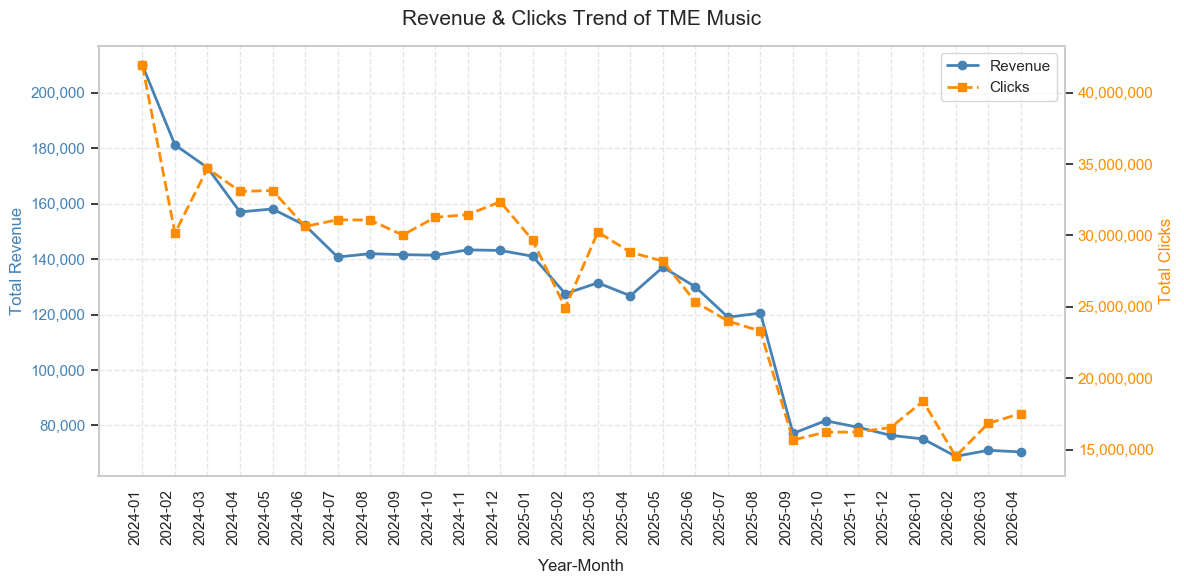

In [327]:
revenue_by_month = (
    df_cleaned.groupby('YearMonth')
    .agg(revenue=('Revenue', 'sum'), clicks=('Total_Clicks', 'sum'))
    .reset_index()
)
revenue_by_month['Rev_MoM_Growth'] = (
    revenue_by_month['revenue']
    .pct_change()
    .apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
)

revenue_by_month['Click_MoM_Growth'] = (
    revenue_by_month['clicks']
    .pct_change()
    .apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
)

new_order = ['YearMonth', 'clicks', 'Click_MoM_Growth', 'revenue','Rev_MoM_Growth']
revenue_by_month = revenue_by_month[new_order]
print("Monthly Revenue and Clicks Summary:")
display(revenue_by_month)

# Plot revenue trend line graph and Save to folder
chart_filename = "TME_Revenue_Clicks_Trend.png"
save_file_path = os.path.join(OUTPUT_CHART_PATH, chart_filename)

plotting.plot_revenue_clicks_trend(revenue_by_month, save_path=save_file_path)

## Filter for Specific Analysis Period
Filter the dataset for the designated target period (e.g. 2024-01 to 2026-03).

In [328]:
START_MONTH = "2023-01"
END_MONTH = "2026-06"

df_filtered = df_cleaned[
    (df_cleaned['YearMonth'] >= START_MONTH) & 
    (df_cleaned['YearMonth'] <= END_MONTH)
]
print(f"Filtered dataset from {START_MONTH} to {END_MONTH} contains {len(df_filtered)} rows.")

Filtered dataset from 2023-01 to 2026-06 contains 285899 rows.


## Top Songs Share (dup ISRC)

In [329]:
df_filtered.head()

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
165345,2024-01,UltimateMusic,浪荡江山,HKG631895009,郑少秋,笑看风云,UPC-4715202900930,0.000000,1,aiting_song_outside_detail_CON02-TME00-2023073...,浪荡江山,郑少秋
166708,2024-01,Kugou,郎归晚(Live),HKG631895046,汪明荃,汪明荃演唱会,UPC-4715202900978,8.629039,516,song_outside_detail_CON02-TME00-20230731-0006_...,郎归晚(Live),汪明荃
166707,2024-01,Kugou,千王群英会(Live),HKG631895045,汪明荃,汪明荃演唱会,UPC-4715202900978,0.138293,114,song_outside_detail_CON02-TME00-20230731-0006_...,千王群英会(Live),汪明荃
166706,2024-01,Kugou,用爱将心偷(Live),HKG631895044,汪明荃,汪明荃演唱会,UPC-4715202900978,28.407109,1565,song_outside_detail_CON02-TME00-20230731-0006_...,用爱将心偷(Live),汪明荃
166705,2024-01,Kugou,笑看风云(Live),HKG631895043,郑少秋,汪明荃演唱会,UPC-4715202900978,124.408332,40075,song_outside_detail_CON02-TME00-20230731-0006_...,笑看风云(Live),郑少秋


In [330]:
revenue_by_song = (
    df_filtered
    .groupby(['UPC', 'ISRC'])
    .agg(
        album=('Album', 'first'),
        song=('standard_song', 'first'),
        artist=('standard_artist', 'first'),
        revenue=('Revenue', 'sum'),
        clicks=('Total_Clicks', 'sum')
    )
    .reset_index()
)
revenue_by_song = revenue_by_song.sort_values('revenue', ascending=False)

In [331]:
total_rev = revenue_by_song['revenue'].sum()
total_clicks = revenue_by_song['clicks'].sum()

revenue_by_song_top = revenue_by_song.head(TOP_N_SONGS).copy()
revenue_by_song_top['revenue_share'] = revenue_by_song_top['revenue'] / total_rev
revenue_by_song_top['click_share'] = revenue_by_song_top['clicks'] / total_clicks
top_song_list = revenue_by_song_top['ISRC'].tolist()

print(f"Top {TOP_N_SONGS} songs contribute to {revenue_by_song_top['revenue_share'].sum():.2%} of total revenue.")
display(revenue_by_song_top)

# Side-by-side pie charts for revenue & clicks contribution
top_song_detail = revenue_by_song.head(TOP_N_SONGS).copy()[['song', 'revenue', 'clicks']]
other_songs_rev = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['revenue'].sum()
other_songs_clicks = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['clicks'].sum()

others_row = pd.DataFrame([{
    'song': 'Others',
    'revenue': other_songs_rev,
    'clicks': other_songs_clicks
}])

df_pie = pd.concat([top_song_detail, others_row], ignore_index=True)

pie_chart_filename = "Song_Contribution_Pie.png"
save_pie_path = os.path.join(OUTPUT_CHART_PATH, pie_chart_filename)
# plotting.plot_pie_charts(df_pie, save_path=save_pie_path)

Top 10 songs contribute to 74.89% of total revenue.


,UPC,ISRC,album,song,artist,revenue,clicks,revenue_share,click_share
551,UPC-4715202900930,HKG631895001,笑看风云,笑看风云,郑少秋,1.098876e+06,215730315,0.312499,0.292558
392,UPC-4715202900800,HKG631892001,我是情痴·随缘,随缘,温兆伦,4.233959e+05,68497643,0.120405,0.092892
496,UPC-4715202900909,HKG631892001,投入生命,随缘,温兆伦,4.077443e+05,75084237,0.115954,0.101824
200,UPC-4715202900633,HKG631882039,万水千山总是情 电视剧原声带,万水千山总是情,汪明荃,1.955994e+05,50588017,0.055625,0.068604
241,UPC-4715202900671,HKG631882039,金曲精选,万水千山总是情,汪明荃,1.328907e+05,40822243,0.037792,0.055360
473,UPC-4715202900879,HKG631893007,大时代,摘下满天星,郑少秋,1.289598e+05,23110428,0.036674,0.031341
505,UPC-4715202900916,HKG631894001,天边洒的不是雨,缘份,陈松伶,6.557750e+04,15113934,0.018649,0.020496
908,UPC-4715202901241,HKG631895019,国语最佳精选辑,天地情缘,温兆伦,6.185979e+04,14046427,0.017592,0.019049
618,UPC-4715202900985,HKG631896029,天地男儿,从不放弃,郑少秋,6.129147e+04,9453679,0.017430,0.012820
832,UPC-4715202901173,HKG631878001,小李飞刀,小李飞刀,罗文,5.737533e+04,10100543,0.016316,0.013698


## Top Songs Share (unique ISRC)

In [332]:
# unique ISRC, exclude duplicate UPC
revenue_by_song_unique_ISRC = (
    revenue_by_song
    .groupby('ISRC')
    .agg(
        # album=('album', 'first'),
        song=('song', 'first'),
        artist=('artist', 'first'),
        revenue=('revenue', 'sum'),
        clicks=('clicks', 'sum')
    )
    .reset_index()
)
revenue_by_song_unique_ISRC = revenue_by_song_unique_ISRC.sort_values('revenue', ascending=False)


Top 10 songs contribute to 78.46% of total revenue.


,ISRC,song,artist,revenue,clicks,revenue_share,click_share
763,HKG631895001,笑看风云,郑少秋,1.098876e+06,215730315,0.312499,0.292558
643,HKG631892001,随缘,温兆伦,8.311401e+05,143581880,0.236360,0.194715
432,HKG631882039,万水千山总是情,汪明荃,3.541802e+05,94487826,0.100722,0.128138
693,HKG631893007,摘下满天星,郑少秋,1.289598e+05,23110428,0.036674,0.031341
726,HKG631894001,缘份,陈松伶,6.557750e+04,15113934,0.018649,0.020496
194,HKG631878001,小李飞刀,罗文,6.317155e+04,11468090,0.017965,0.015552
777,HKG631895019,天地情缘,温兆伦,6.185979e+04,14046427,0.017592,0.019049
853,HKG631896029,从不放弃,郑少秋,6.129147e+04,9453679,0.017430,0.012820
634,HKG631891029,正义柔情永在,"温兆伦, 陈松伶",4.711659e+04,9740390,0.013399,0.013209
622,HKG631891016,从未试过拥有,温兆伦,4.683022e+04,12444932,0.013318,0.016877


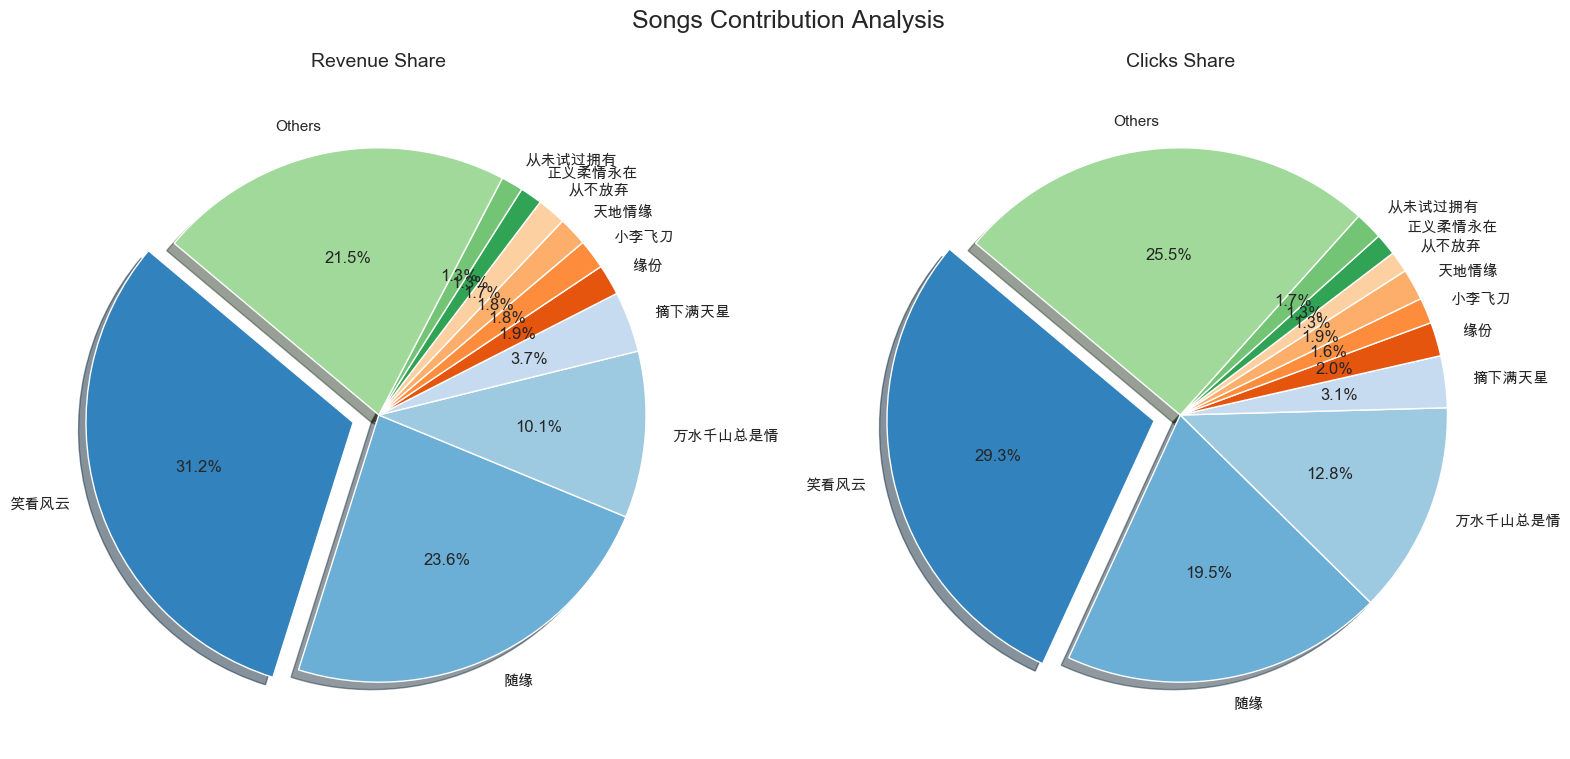

Top 30 songs contribute to 89.81% of total revenue.


,ISRC,song,artist,revenue,clicks,revenue_share,click_share
763,HKG631895001,笑看风云,郑少秋,1.098876e+06,215730315,0.312499,0.292558
643,HKG631892001,随缘,温兆伦,8.311401e+05,143581880,0.236360,0.194715
432,HKG631882039,万水千山总是情,汪明荃,3.541802e+05,94487826,0.100722,0.128138
693,HKG631893007,摘下满天星,郑少秋,1.289598e+05,23110428,0.036674,0.031341
726,HKG631894001,缘份,陈松伶,6.557750e+04,15113934,0.018649,0.020496
194,HKG631878001,小李飞刀,罗文,6.317155e+04,11468090,0.017965,0.015552
777,HKG631895019,天地情缘,温兆伦,6.185979e+04,14046427,0.017592,0.019049
853,HKG631896029,从不放弃,郑少秋,6.129147e+04,9453679,0.017430,0.012820
634,HKG631891029,正义柔情永在,"温兆伦, 陈松伶",4.711659e+04,9740390,0.013399,0.013209
622,HKG631891016,从未试过拥有,温兆伦,4.683022e+04,12444932,0.013318,0.016877


In [333]:
# plot pie chart
total_rev = revenue_by_song_unique_ISRC['revenue'].sum()
total_clicks = revenue_by_song_unique_ISRC['clicks'].sum()

revenue_by_song_top_unique_ISRC = revenue_by_song_unique_ISRC.head(TOP_N_SONGS).copy()
revenue_by_song_top_unique_ISRC['revenue_share'] = revenue_by_song_top_unique_ISRC['revenue'] / total_rev
revenue_by_song_top_unique_ISRC['click_share'] = revenue_by_song_top_unique_ISRC['clicks'] / total_clicks
top_song_list = revenue_by_song_top_unique_ISRC['ISRC'].tolist()

print(f"Top {TOP_N_SONGS} songs contribute to {revenue_by_song_top_unique_ISRC['revenue_share'].sum():.2%} of total revenue.")
display(revenue_by_song_top_unique_ISRC)

# Side-by-side pie charts for revenue & clicks contribution
top_song_detail = revenue_by_song_unique_ISRC.head(TOP_N_SONGS).copy()[['song', 'revenue', 'clicks']]
other_songs_rev = revenue_by_song_unique_ISRC[~revenue_by_song_unique_ISRC['ISRC'].isin(top_song_list)]['revenue'].sum()
other_songs_clicks = revenue_by_song_unique_ISRC[~revenue_by_song_unique_ISRC['ISRC'].isin(top_song_list)]['clicks'].sum()

others_row = pd.DataFrame([{
    'song': 'Others',
    'revenue': other_songs_rev,
    'clicks': other_songs_clicks
}])

df_pie = pd.concat([top_song_detail, others_row], ignore_index=True)

pie_chart_filename = "Song_Contribution_Pie_Unique_ISRC.png"
save_pie_path = os.path.join(OUTPUT_CHART_PATH, pie_chart_filename)
plotting.plot_pie_charts(df_pie, save_path=save_pie_path)

# generate top N report
revenue_by_song_topN_unique_ISRC = revenue_by_song_unique_ISRC.head(TOP_N_SONGS_UNIQUE_ISRC).copy()
revenue_by_song_topN_unique_ISRC['revenue_share'] = revenue_by_song_topN_unique_ISRC['revenue'] / total_rev
revenue_by_song_topN_unique_ISRC['click_share'] = revenue_by_song_topN_unique_ISRC['clicks'] / total_clicks
top30_song_list = revenue_by_song_topN_unique_ISRC['ISRC'].tolist()

print(f"Top {TOP_N_SONGS_UNIQUE_ISRC} songs contribute to {revenue_by_song_topN_unique_ISRC['revenue_share'].sum():.2%} of total revenue.")
display(revenue_by_song_topN_unique_ISRC)


## Generate Song Report
Aggregates, pivots, and exports monthly metrics to Excel.

In [334]:
song_final = generate_song_report(df_filtered, OUTPUT_SONG_REPORT_PATH_MONTHLY)
song_final.head()

Song report exported successfully to: ../output/FORWARD/TME_Song_Report_Monthly_Forward.xlsx


,ISRC,song,artist,UPC,album,total_click,total_revenue,2024-01_clicks,2024-01_revenue,2024-02_clicks,...,2025-12_clicks,2025-12_revenue,2026-01_clicks,2026-01_revenue,2026-02_clicks,2026-02_revenue,2026-03_clicks,2026-03_revenue,2026-04_clicks,2026-04_revenue
0,HKG631895001,笑看风云,郑少秋,UPC-4715202900930,笑看风云,215730315,1.098876e+06,12551280,66241.968418,9789967,...,0,0.000000,2390068,5328.494253,1781473,3760.102854,1903305,3251.710876,3009001,6597.125502
1,HKG631892001,随缘,温兆伦,UPC-4715202900800,我是情痴·随缘,68497643,4.233959e+05,7333158,47152.967315,4029332,...,1873578,11325.700960,1811273,9320.687824,1572396,9382.119456,1693831,8760.517125,1715161,8498.565327
2,HKG631892001,随缘,温兆伦,UPC-4715202900909,投入生命,75084237,4.077443e+05,6050976,31024.625351,3382755,...,2412381,11487.407443,2404375,10381.962677,1873381,9836.923195,2323522,10108.575414,2332945,9913.993457
3,HKG631882039,万水千山总是情,汪明荃,UPC-4715202900633,万水千山总是情 电视剧原声带,50588017,1.955994e+05,2161371,7674.824207,2048345,...,1304120,6023.323827,1044828,5159.672531,870320,4985.058082,955162,4842.801410,962915,4601.108473
4,HKG631882039,万水千山总是情,汪明荃,UPC-4715202900671,金曲精选,40822243,1.328907e+05,1661393,5215.694363,1431046,...,1012740,3667.515475,1026187,3756.540136,823857,3365.033480,945043,3454.489675,903543,3351.519916


## Monthly Revenue Trend for Top Songs

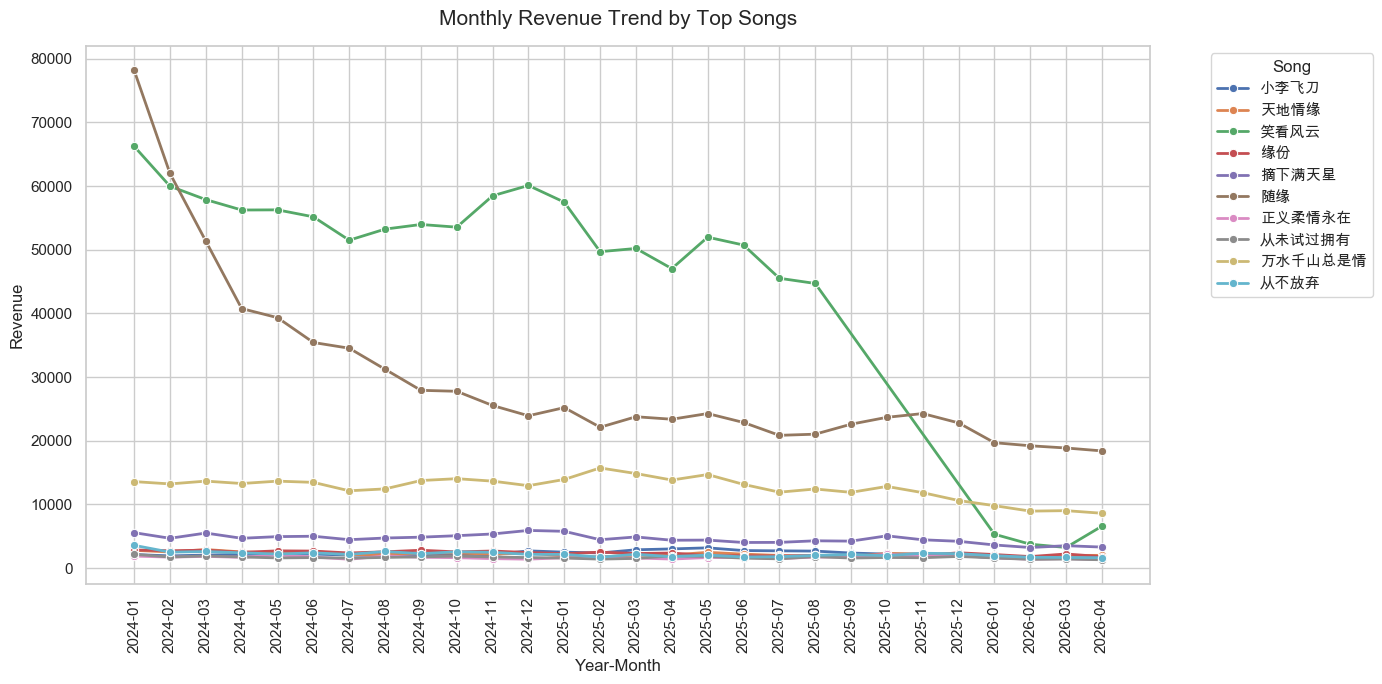

In [335]:
revenue_by_song_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth'])
    .agg(
        song=('standard_song', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
monthly_revenue_top_song = revenue_by_song_per_month[revenue_by_song_per_month['ISRC'].isin(top_song_list)].sort_values('YearMonth')

song_trend_path = os.path.join(OUTPUT_CHART_PATH, "Monthly_Revenue_by_Top_Songs.png")
plotting.plot_monthly_revenue_by_top_songs(monthly_revenue_top_song, TOP_N_SONGS, save_path=song_trend_path)

## Revenue by Platform

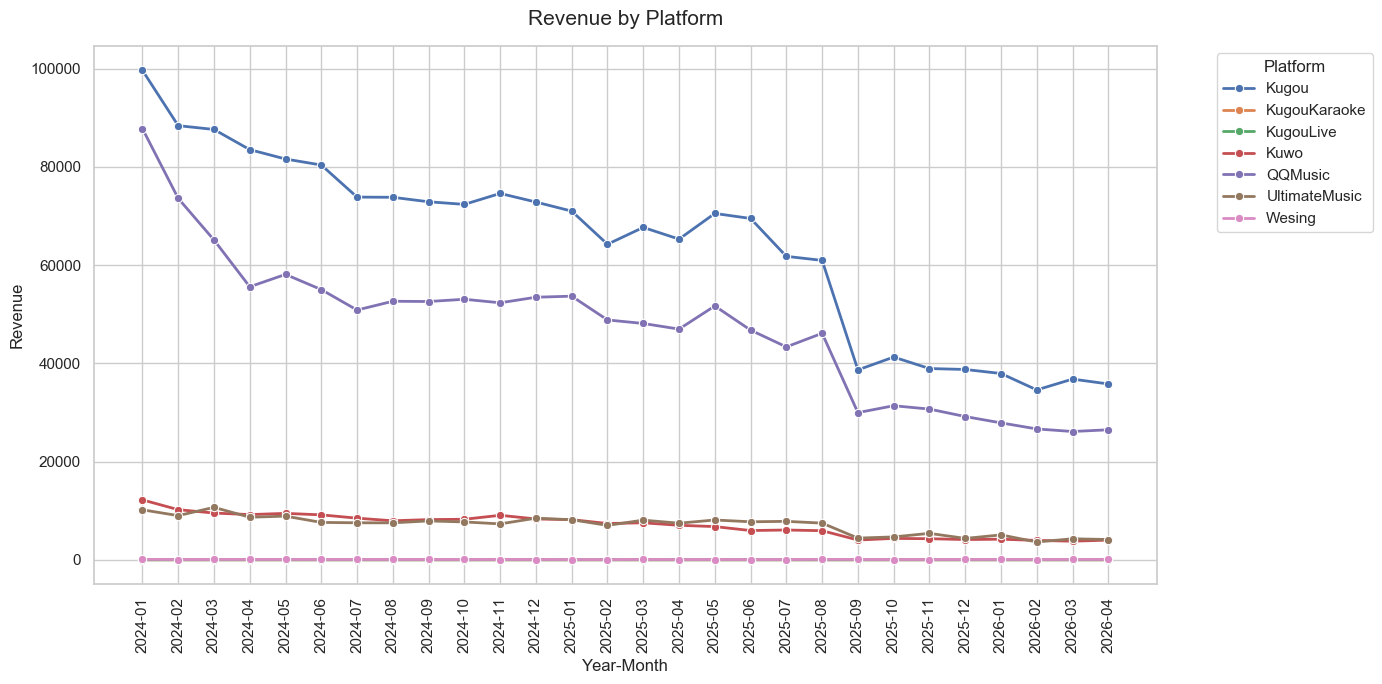

In [336]:
revenue_by_platform_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth', 'Platform'])
    .agg(revenue=('Revenue', 'sum'))
    .reset_index()
)
revenue_by_platform = (
    revenue_by_platform_per_month
    .groupby(['YearMonth', 'Platform'])
    .agg(revenue=('revenue', 'sum'))
    .reset_index()
)

platform_trend_path = os.path.join(OUTPUT_CHART_PATH, "Revenue_by_Platform.png")
plotting.plot_revenue_by_platform(revenue_by_platform, save_path=platform_trend_path)

## Generate Album Report & Plot Revenue by Album

In [337]:
# Generate Excel report for Albums
# album_final = generate_album_report(df_filtered, OUTPUT_ALBUM_REPORT_PATH)
# display(album_final.head())

# Find top albums contribute to total revenue
revenue_by_album = (
    df_filtered
    .groupby(['UPC'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
revenue_by_album = revenue_by_album.sort_values('revenue', ascending=False)
print(f"Top {TOP_N_ALBUMS} albums contribute to {revenue_by_album['revenue'].head(TOP_N_ALBUMS).sum()/revenue_by_album['revenue'].sum():.2%} of total revenue.")

# Plot monthly trend lines for the top albums
top_n_album_list = revenue_by_album['UPC'].head(TOP_N_ALBUMS).tolist()
revenue_by_album_per_month = (
    df_filtered
    .groupby(['UPC', 'YearMonth'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
top_album_trend = revenue_by_album_per_month[
    revenue_by_album_per_month['UPC'].isin(top_n_album_list)
]

album_trend_path = os.path.join(OUTPUT_CHART_PATH, "Revenue_by_Album.png")
# plotting.plot_revenue_by_album(top_album_trend, save_path=album_trend_path)

Top 10 albums contribute to 81.65% of total revenue.


## Find Missing ISRC Song

In [338]:
# df_with_dash = song_final[song_final['ISRC'].str.contains('-')]
# df_with_dash = df_with_dash[['ISRC', 'song', 'artist', 'UPC', 'album']]
# df_with_dash

## Generate in one Excel file

In [339]:
sheets_dict = {
    'Monthly_Rev_Click': song_final,
    'Total_Revenue': revenue_by_month,
    'Top_30': revenue_by_song_topN_unique_ISRC,
    # 'Missing_ISRC': missing_isrc,
    # 'Missing_UPC': missing_upc,
    # 'Song_mismatch': song_mismatch,
    # 'Artist_mismatch': artist_mismatch,
}

with pd.ExcelWriter(OUTPUT_ALL_REPORT_PATH, engine='openpyxl') as writer:
    for sheet_name, df in sheets_dict.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

reporting.style_excel_file(OUTPUT_ALL_REPORT_PATH)

## Compare Two Files

In [340]:
FILE1_PATH = "/Users/chu-chun/Mirror/Eva/output/FORWARD/TME_Song_Report_Monthly_Forward.xlsx"
FILE2_PATH = "/Users/chu-chun/Mirror/Eva/output/FORWARD/TME_Song_Report_Monthly_Forward_old.xlsx"

df1 = pd.read_excel(FILE1_PATH)
df2 = pd.read_excel(FILE2_PATH)

# 合併 col1 + col2 形成比較用 key
df1["key"] = df1["ISRC"].astype(str) + "_" + df1["UPC"].astype(str)
df2["key"] = df2["ISRC"].astype(str) + "_" + df2["song"].astype(str)

result = df1[["key"]].merge(
    df2[["key"]],
    on="key",
    how="outer",
    indicator=True
)

print(result["_merge"].value_counts())

only_in_file1 = result[result["_merge"] == "left_only"]
only_in_file2 = result[result["_merge"] == "right_only"]

_merge
right_only    1221
left_only     1076
both             0
Name: count, dtype: int64


In [341]:
print(df1["key"].duplicated().sum())
print(df2["key"].duplicated().sum())

0
207


In [342]:
print("df1 rows =", len(df1))
print("df1 unique =", df1["key"].nunique())

print("df2 rows =", len(df2))
print("df2 unique =", df2["key"].nunique())

df1 rows = 1076
df1 unique = 1076
df2 rows = 1221
df2 unique = 1014


In [343]:
dup_keys = df1.loc[df1["key"].duplicated(keep=False), "key"]
print(dup_keys.unique())

[]
